In [1]:
# import all necessary libraries
import numpy as np
import pandas as pd
import h5py
import vaex
import pynbody
from pynbody.array import SimArray
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import PathPatch
from pathlib import Path as path
from astropy import units as u
from astropy.io import ascii, fits
from astropy.table import Table, vstack
from astropy.coordinates import SkyCoord,CartesianRepresentation,match_coordinates_sky
import functions as fn 
import matched_filter_ani as mf

np.random.seed(0)

In [2]:
# define the name of the galaxy, its distance, depth, resolution, other parameters and filepaths
box = 'rogue' 
num = 5
D = 2000
mlim_str = '26p5' 
name = f'{box}_4096_{num}_data_{D}_{mlim_str}'
rmaglim = 26

size_kpc = 40 
pdist = (size_kpc/D) * (180/np.pi) 
year = 10
mlim = '26'
c1='px'
c2='py'
edgelength = 10 
plotdir = f'{box}_4096_{num}' 
bgcatpath = f"mf_data/bgcats/bgr{mlim}g{mlim}_for_mf_{int(edgelength)}deg.fits"

age = '10'
mh = '-2'

In [3]:
# load background data
bgcat = Table.read(bgcatpath,format='fits')
c1bg = bgcat['c1']
c2bg = bgcat['c2']

bgtable = Table()
bgtable['c1'] = c1bg
bgtable['c2'] = c2bg
bgtable['gmag'] = bgcat['gmag']
bgtable['Ag'] = bgcat['Ag'] 
bgtable['rmag'] = bgcat['rmag']
bgtable['Ar'] = bgcat['Ar']
bgtable['flag'] = 'bg'
bgtable['age'] = -99

In [4]:
def fibonacci_angler(n):
    """ Generates n evenly spaced angles in spherical polar coordinates.

    Args:
        n (int):
            Number of desired evenly spaced angles.

    Returns:
        declination_array ((array of) float(s)):
            The declination(s) of the generated angle(s).
        azimuthal_array ((array of) float(s)):
            The azimuth(s) of the generated angle(s).
    """

    golden_ratio = (1 + np.sqrt(5))/2

    i_array = np.linspace(0,n-1,n)
    z_array = 1 - i_array/(n-1) ###ONLY GOES HALF WAY DOWN
    radius_array = np.sqrt(1-z_array**2)

    declination_array = np.pi/2-np.arcsin(z_array)
    azimuthal_array = 2*np.pi * i_array/golden_ratio

    declination_readable = [round(x*180/np.pi,1) for x in declination_array]
    azimuthal_readable = [round(np.mod(x*180/np.pi, 360),1) for x in  azimuthal_array]

    return declination_readable, azimuthal_readable

In [10]:
# allows for manual selection of unrun angles. Get rid of index splicing if you want all angles. Hardcoded for 24 angles.
declination_readable, azimuthal_readable = fibonacci_angler(24)
print(declination_readable, '\n', azimuthal_readable, '\n')
dec=[49.3, 52.5, 55.6, 58.6, 85.0, 87.5, 90.0]
azi=[339.9, 202.4, 64.9, 287.4, 352.3, 214.8, 77.3]
print(dec, '\n', azi, '\n')

[0.0, 17.0, 24.1, 29.6, 34.3, 38.5, 42.3, 45.9, 49.3, 52.5, 55.6, 58.6, 61.4, 64.2, 67.0, 69.6, 72.3, 74.9, 77.4, 80.0, 82.5, 85.0, 87.5, 90.0] 
 [0.0, 222.5, 85.0, 307.5, 170.0, 32.5, 255.0, 117.4, 339.9, 202.4, 64.9, 287.4, 149.9, 12.4, 234.9, 97.4, 319.9, 182.4, 44.9, 267.4, 129.8, 352.3, 214.8, 77.3] 

[49.3, 52.5, 55.6, 58.6, 85.0, 87.5, 90.0] 
 [339.9, 202.4, 64.9, 287.4, 352.3, 214.8, 77.3] 



In [11]:
# add background data to all the rotations and saves it.
# ONLY RUN IF THESE FILES DON'T ALREADY EXIST (running this won't break anything, but is very time-consuming)
# for i in range(len(dec)):
            
#     # shortcuts
#     d = dec[i] 
#     a = azi[i]
             
#     dwarfcatpath = f"/home/giantsid/MAP/matched_filter/mf_data/rotated_catalogs/{rmaglim}_{D}/{box}_{num}/{box}_{num}_d={d}_a={a}.h5"
#     save_path = path(f"/home/giantsid/MAP/matched_filter/mf_data/bg_added_catalogs/{rmaglim}_{D}/{box}_{num}/bg_{box}_{num}_d={d}_a={a}.fits")
#     save_path.parent.mkdir(parents=True, exist_ok=True)

#     # add dwarf data to background data. Save.
#     dwarf_table = fn.bg_dwarf_combo(pdist,name,year,D,c1,c2,plotdir,dwarfcatpath,bgcatpath,edgelength,plot=False,save=True,my_save_path = save_path) 
#     table_final = vstack([dwarf_table,bgtable])
#     table_final.write(save_path,format='fits',overwrite=True)

In [12]:
# more parameter defition
numpix = 8000
iso_info = 'parsec'
pix = (np.round(np.sqrt((2*pdist*60)**2 / numpix),2))
catalog = f'mf_data/bgcats/bgr26g26_for_mf_10deg.fits'
field = name+f'_mfmag{rmaglim}_{iso_info}{age}{mh}{c1}{c2}_{np.round(pdist*60,0)}'
signal_file = f"mf_data/signals/{iso_info}_{D}_{age}{mh}_signal_cmd_gr.txt"

Total number of signal CMD
1.0


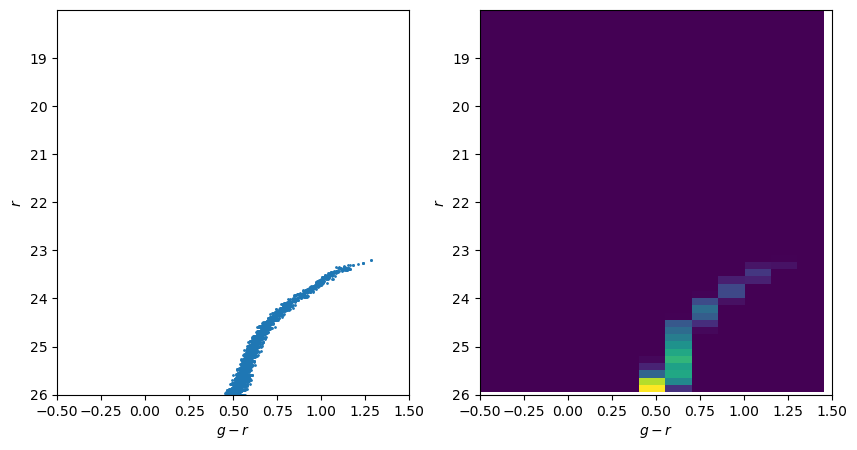

In [ ]:
# create CMDs
objcmd = mf.mk_norm_objcmd_gd(field, signal_file, rmaglim=rmaglim, plot=True)   
backcmd = mf.mk_norm_backcmd(field, catalog, rmaglim=rmaglim, plot=True, pix=pix)

In [ ]:
# MFA
for i in range(len(dec)):
            
    # shortcuts
    d = dec[i] 
    a = azi[i]

    # from background-added catalogs to matched-filter catalogs
    save_path = f"mf_data/bg_added_catalogs/{rmaglim}_{D}/{box}_{num}/bg_{box}_{num}_d={d}_a={a}.fits"
    second_save_path_check = path(f"mf_data/mf_catalogs/{rmaglim}_{D}/{box}_{num}")
    second_save_path_check.parent.mkdir(parents=True, exist_ok=True)
    second_save_path = f"mf_data/mf_catalogs/{rmaglim}_{D}/{box}_{num}/mf_{box}_{num}_d={d}_a={a}_pix={numpix}.fits"
    
    # run matched filter analysis
    mf.matched_filter_ani(objcmd, backcmd, second_save_path,
        field=field, 
        catalog=save_path,
        plot=True, rmaglim = rmaglim, pix=pix, pdist=pdist*60)